C:\Users\admin\AppData\Local\Temp\ipykernel_8332\3128391758.py:7: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  temperature_2m = df.pivot("Latitude", "Longitude", "Temperature").values


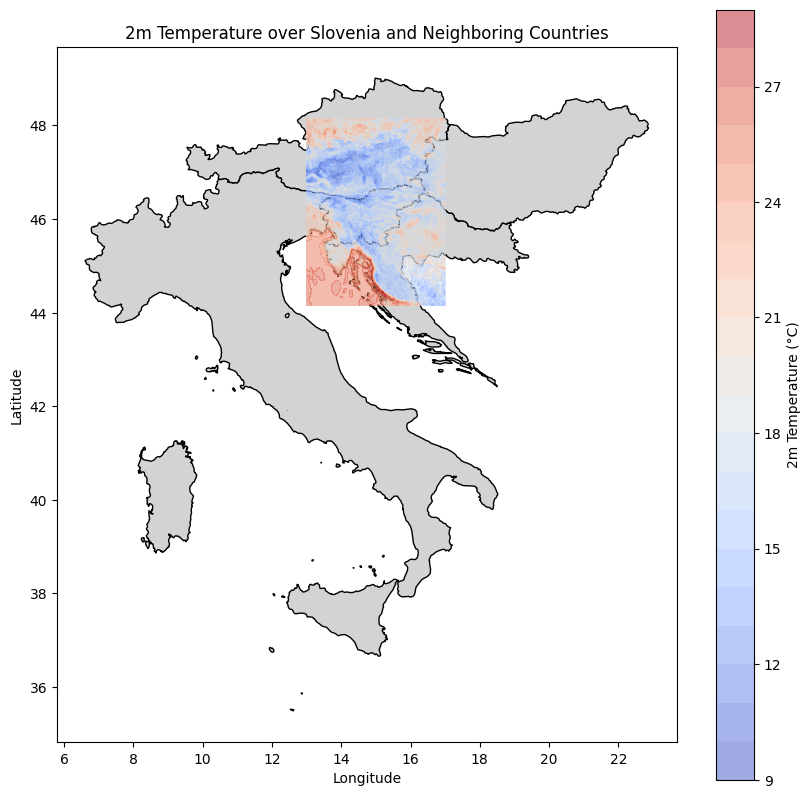

In [5]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Read the temperature data
df = pd.read_csv('temperature_data_2_2_2_2.csv')
temperature_2m = df.pivot("Latitude", "Longitude", "Temperature").values
lat_values = df['Latitude'].unique()
lon_values = df['Longitude'].unique()

# Read the detailed world map
world = gpd.read_file('./shape/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')

# Filter countries
countries = ['Slovenia', 'Austria', 'Italy', 'Hungary', 'Croatia']
region = world[world['SOVEREIGNT'].isin(countries)]

# Plot the map
fig, ax = plt.subplots(figsize=(10, 10))
region.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot the 2m temperature
plt.contourf(lon_values, lat_values, temperature_2m, 20, cmap='coolwarm', alpha=0.5)
plt.colorbar(label="2m Temperature (°C)")

plt.title("2m Temperature over Slovenia and Neighboring Countries")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
